<a href="https://colab.research.google.com/github/unVeroz007/2311532008_Muhammad-Galis-Avero_ImageProcessing/blob/main/Pertemuan6/Tugas_Pertemuan_6_Image_Processing_Muhammad_Galid_Avero_2311532008.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Import Library


In [27]:
import numpy as np
import cv2
from matplotlib import pyplot as plt

#1. Baca Citra (grayscale)

In [28]:
img = cv2.imread('image.png', 0)
rows, cols = img.shape

#2. Hitung DFT (menggunakan FFT secara otomatis)

In [29]:
dft = cv2.dft(np.float32(img), flags=cv2.DFT_COMPLEX_OUTPUT)

#3. Shift DC component ke tengah untuk visualisasi

In [30]:
dft_shift = np.fft.fftshift(dft)

#4. Hitung magnitude spectrum (untuk visualisasi)

In [31]:
Magnitude = 20*np.log(np.sqrt(dft_shift[:,:,0]**2 + dft_shift[:,:,1]**2) + 1e-10)
magnitude_spectrum = 20 * np.log(cv2.magnitude(
dft_shift[:,:,0], dft_shift[:,:,1]
) + 1e-10)

#5. Buat Low-Pass Filter (mask lingkaran di tengah)

In [32]:
crow, ccol = rows // 2, cols // 2 # posisi tengah
radius = 30 # ukuran radius filter (cutoff frequency)

Mask dengan 2 channels (real dan imaginary)

In [33]:
mask = np.zeros((rows, cols, 2), np.uint8)
cv2.circle(mask, (ccol, crow), radius, (1, 1), -1)

array([[[0, 0],
        [0, 0],
        [0, 0],
        ...,
        [0, 0],
        [0, 0],
        [0, 0]],

       [[0, 0],
        [0, 0],
        [0, 0],
        ...,
        [0, 0],
        [0, 0],
        [0, 0]],

       [[0, 0],
        [0, 0],
        [0, 0],
        ...,
        [0, 0],
        [0, 0],
        [0, 0]],

       ...,

       [[0, 0],
        [0, 0],
        [0, 0],
        ...,
        [0, 0],
        [0, 0],
        [0, 0]],

       [[0, 0],
        [0, 0],
        [0, 0],
        ...,
        [0, 0],
        [0, 0],
        [0, 0]],

       [[0, 0],
        [0, 0],
        [0, 0],
        ...,
        [0, 0],
        [0, 0],
        [0, 0]]], dtype=uint8)

#6. Aplikasikan filter (perkalian di domain frekuensi)

In [34]:
fshift = dft_shift * mask

#7. Inverse shift (kembalikan DC ke pojok)

In [35]:
f_ishift = np.fft.ifftshift(fshift)

#8. Inverse DFT (kembali ke domain spasial)

In [36]:
img_back = cv2.idft(f_ishift)
img_back = cv2.magnitude(img_back[:,:,0], img_back[:,:,1])

#9. Visualisasi hasil

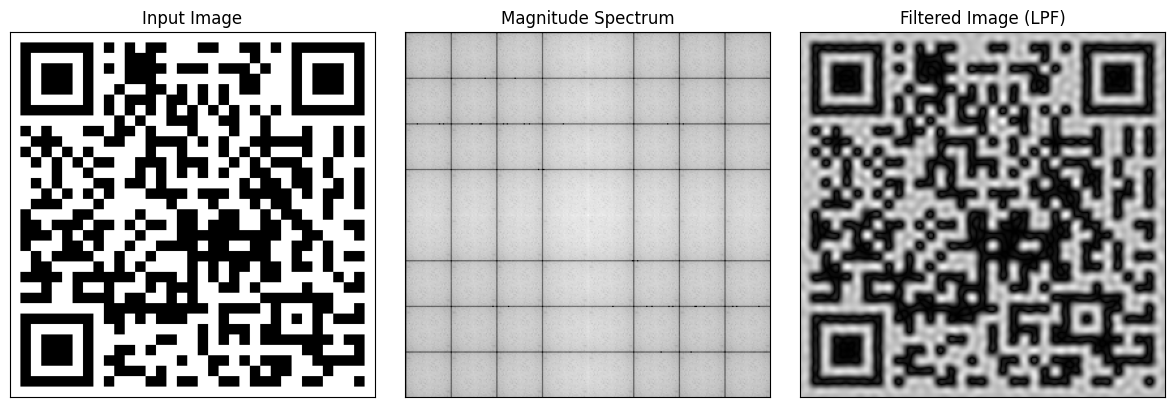

In [37]:
plt.figure(figsize=(12, 4))

plt.subplot(131)
plt.imshow(img, cmap='gray')
plt.title('Input Image')
plt.xticks([]), plt.yticks([])

plt.subplot(132)
plt.imshow(magnitude_spectrum, cmap='gray')
plt.title('Magnitude Spectrum')
plt.xticks([]), plt.yticks([])

plt.subplot(133)
plt.imshow(img_back, cmap='gray')
plt.title('Filtered Image (LPF)')
plt.xticks([]), plt.yticks([])

plt.tight_layout()
plt.show()